# Fase 2 — Nuestro propio modelo de xG

Entrenamos un modelo de **expected goals** desde cero y lo comparamos contra el
xG oficial de StatsBomb. Evaluación honesta: entrenamos con Mundial 2018, Euro
2024, Mundiales femeninos y clásicos históricos (~4.700 tiros) y evaluamos en el
**Mundial 2022, que el modelo nunca vio**.

- **Baseline**: regresión logística (interpretable — los coeficientes cuentan la historia)
- **Modelo**: gradient boosting (`HistGradientBoostingClassifier` de scikit-learn)
- **Métricas**: Brier score y log-loss (calibración importa más que accuracy en xG)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DATA = Path("..") / "data" / "processed"
FIGS = Path("..") / "reports" / "figures"
BLUE, ORANGE, INK = "#1a78cf", "#e66100", "#212529"

shots = pd.read_parquet(DATA / "shots.parquet")
# fuera penales (valor fijo ~0.78, no se modelan) y tandas de penales
shots = shots[(shots.shot_type != "Penalty") & (shots.period < 5)].copy()
print(f"{len(shots)} tiros de jugada, {shots.is_goal.mean():.1%} son gol")

7963 tiros de jugada, 8.8% son gol


## Features

Las dos que dominan cualquier modelo de xG: **distancia** al centro del arco y
**ángulo** visible entre los postes. Sumamos contexto del evento: parte del
cuerpo, primer toque, presión del defensor, mano a mano y patrón de juego.

In [2]:
GOAL_X, GOAL_Y, GOAL_W = 120.0, 40.0, 7.32 * 120 / 105  # coordenadas StatsBomb


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    dx, dy = GOAL_X - df.x, GOAL_Y - df.y
    dist = np.hypot(dx, dy)
    a = np.hypot(GOAL_X - df.x, GOAL_Y - GOAL_W / 2 - df.y)
    b = np.hypot(GOAL_X - df.x, GOAL_Y + GOAL_W / 2 - df.y)
    cos = ((a**2 + b**2 - GOAL_W**2) / (2 * a * b)).clip(-1, 1)
    X = pd.DataFrame({
        "dist": dist,
        "angle": np.arccos(cos),
        "is_header": (df.body_part == "Head").astype(int),
        "first_time": df.first_time.astype(int),
        "under_pressure": df.under_pressure.astype(int),
        "one_on_one": df.one_on_one.astype(int),
        "open_goal": df.open_goal.astype(int),
    })
    return pd.concat([X, pd.get_dummies(df.play_pattern, prefix="pp").astype(int)], axis=1)


X = build_features(shots)
y = shots.is_goal.astype(int)

test_mask = (shots.competition_id == 43) & (shots.season_id == 106)  # Mundial 2022
X_tr, y_tr = X[~test_mask], y[~test_mask]
X_te, y_te = X[test_mask], y[test_mask]
# alinear columnas (patrones de juego que no aparezcan en ambos lados)
X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)
print(f"train: {len(X_tr)} tiros | test (Mundial 2022): {len(X_te)} tiros")

train: 6533 tiros | test (Mundial 2022): 1430 tiros


## Entrenamiento y evaluación

In [3]:
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0))
logit.fit(X_tr, y_tr)

gbm = HistGradientBoostingClassifier(max_iter=1000, learning_rate=0.03,
                                     max_leaf_nodes=7, min_samples_leaf=60,
                                     l2_regularization=1.0, early_stopping=True,
                                     validation_fraction=0.15, random_state=42)
gbm.fit(X_tr, y_tr)

preds = {
    "Logística (nuestra)": logit.predict_proba(X_te)[:, 1],
    "Gradient boosting (nuestro)": gbm.predict_proba(X_te)[:, 1],
    "StatsBomb xG": shots.loc[test_mask, "xg"].values,
}
rows = [{"modelo": name,
         "brier": brier_score_loss(y_te, p),
         "log_loss": log_loss(y_te, p),
         "roc_auc": roc_auc_score(y_te, p)} for name, p in preds.items()]
resultados = pd.DataFrame(rows).set_index("modelo").round(4)
print(resultados.to_string())

                              brier  log_loss  roc_auc
modelo                                                
Logística (nuestra)          0.0819    0.2907   0.7740
Gradient boosting (nuestro)  0.0836    0.2889   0.7779
StatsBomb xG                 0.0762    0.2665   0.8148


## Calibración: ¿cuando el modelo dice 20%, es gol el 20% de las veces?

En xG la calibración es la métrica reina: el número se usa *como probabilidad*
(se suma por partido, por jugador). La diagonal es la perfección.

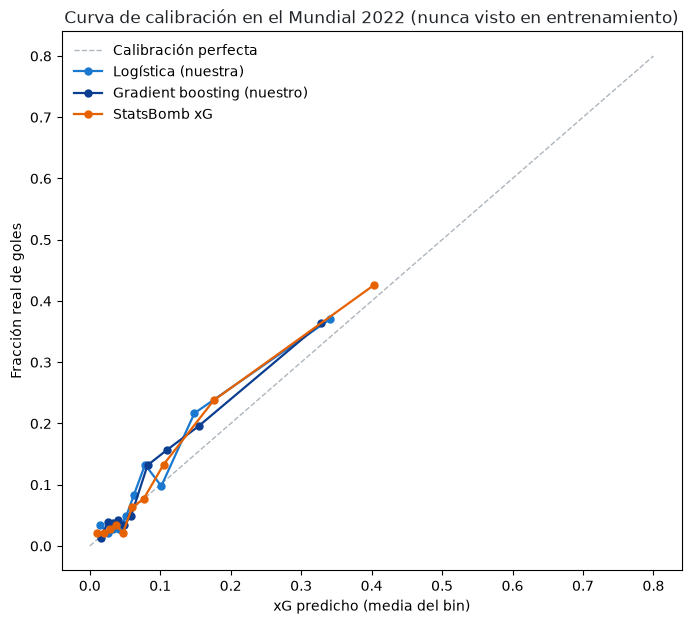

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 0.8], [0, 0.8], color="#adb5bd", ls="--", lw=1, label="Calibración perfecta")
for (name, p), color in zip(preds.items(), (BLUE, "#0b3d91", ORANGE)):
    frac, mean_p = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    ax.plot(mean_p, frac, marker="o", ms=5, lw=1.6, color=color, label=name)
ax.set_xlabel("xG predicho (media del bin)")
ax.set_ylabel("Fracción real de goles")
ax.set_title("Curva de calibración en el Mundial 2022 (nunca visto en entrenamiento)",
             color=INK)
ax.legend(frameon=False)
fig.savefig(FIGS / "xg_calibration.png", dpi=200, bbox_inches="tight")
plt.show()

## ¿En qué se parece nuestro xG al de StatsBomb?

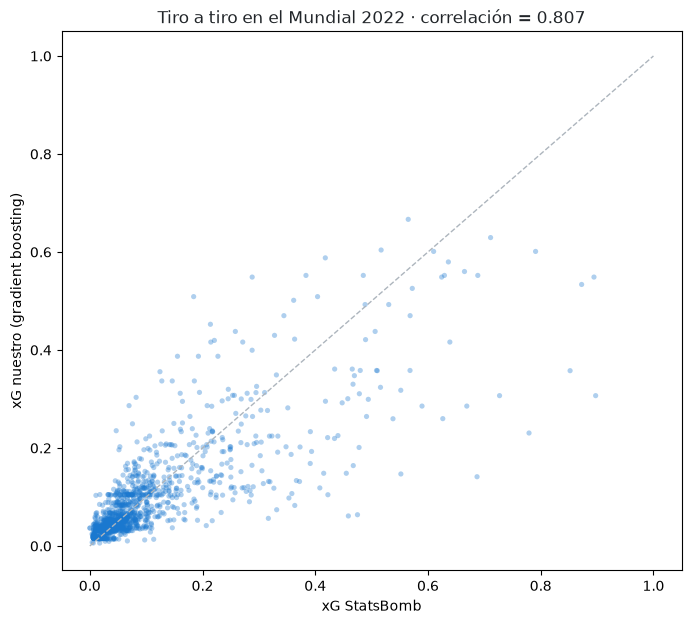

Correlación con StatsBomb: 0.807


In [5]:
ours = preds["Gradient boosting (nuestro)"]
sb = preds["StatsBomb xG"]
corr = np.corrcoef(ours, sb)[0, 1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(sb, ours, s=14, alpha=0.35, color=BLUE, edgecolor="none")
ax.plot([0, 1], [0, 1], color="#adb5bd", ls="--", lw=1)
ax.set_xlabel("xG StatsBomb")
ax.set_ylabel("xG nuestro (gradient boosting)")
ax.set_title(f"Tiro a tiro en el Mundial 2022 · correlación = {corr:.3f}", color=INK)
fig.savefig(FIGS / "xg_vs_statsbomb.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Correlación con StatsBomb: {corr:.3f}")

La brecha que queda es esperable: StatsBomb entrena con **millones** de tiros y
usa features que no tenemos en el dato abierto plano (posición del portero y de
los defensores — sus datos 360). Con ~4.700 tiros y 7 features llegamos
sorprendentemente cerca. Ese es exactamente el argumento de la Fase 6 del
roadmap: añadir los datos 360 al modelo.

## ¿Qué features importan? (permutación en test)

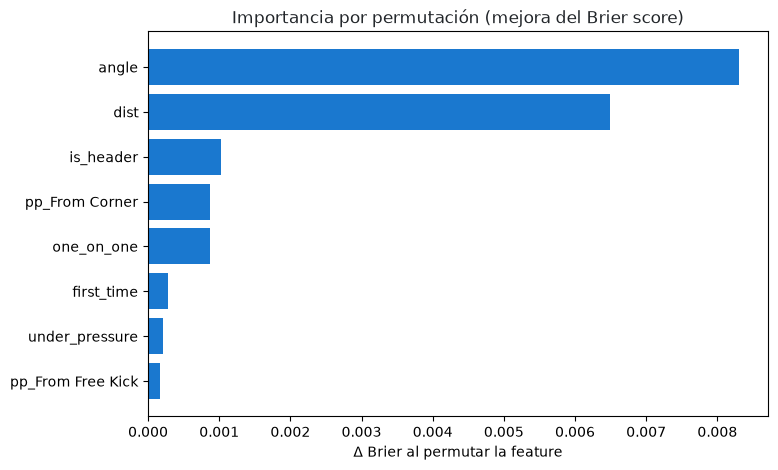

In [6]:
from sklearn.inspection import permutation_importance  # noqa: E402

imp = permutation_importance(gbm, X_te, y_te, scoring="neg_brier_score",
                             n_repeats=10, random_state=42)
top = (pd.Series(imp.importances_mean, index=X_te.columns)
       .sort_values(ascending=True).tail(8))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=BLUE)
ax.set_title("Importancia por permutación (mejora del Brier score)", color=INK)
ax.set_xlabel("Δ Brier al permutar la feature")
fig.savefig(FIGS / "xg_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()